In [1]:
# Author: A.M.Kharazi
# License: BSD 3 clause

# Add to the path

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import optim
from einops import rearrange
from sklearn.model_selection import train_test_split

import tltorch
from Utils.Reshape import reshape
from Utils.Num_parameter import count_parameters

# Synthetic Data

device is set to : cpu


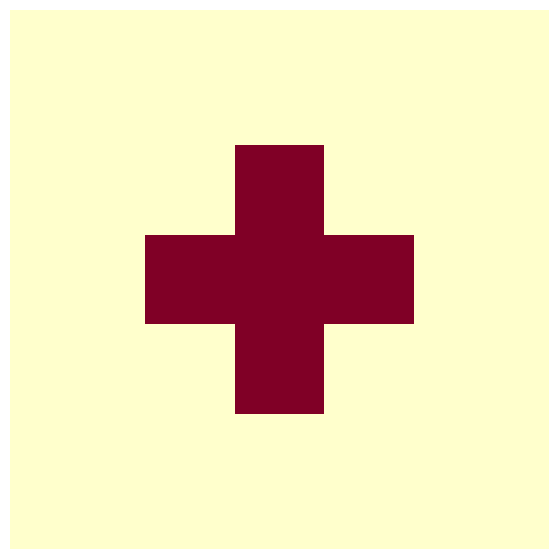

In [40]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is set to : {device}')

def generate_samples(n_samples, size):
    mean = 0
    variance = 3
    std_dev = torch.sqrt(torch.tensor(variance))
    tensor = np.random.normal(mean, std_dev, (n_samples, size))
    tensor = torch.from_numpy(tensor).float()

    
    x, y = np.meshgrid(np.linspace(-3, 3, size), np.linspace(-3, 3, size))

    Weight = np.zeros_like(x)
    Weight[(x >= -0.5) & (x <= 0.5) & (y >= -1.5) & (y <= 1.5)] = 1
    Weight[(y >= -0.5) & (y <= 0.5) & (x >= -1.5) & (x <= 1.5)] = 1
    Weight = torch.from_numpy(Weight).float()

    output  = torch.matmul(tensor, Weight)

    mean = 0
    variance = 1
    std_dev = torch.sqrt(torch.tensor(variance))
    noise = np.random.normal(mean, std_dev, (n_samples, size))
    noise = torch.from_numpy(noise).float()

    return tensor.to(device), output.to(device), Weight.to(device), (tensor+noise).to(device)

n_samples = 100
size = 24

samples, y, W, x = generate_samples(n_samples, size)


fig = plt.figure(figsize=(10,7))
plt.imshow(W.cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title('Ground Truth', fontsize = 20)
plt.show()


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Basic Linear Model

This Model has : 576 parameters
RMSE of Train : 1.240570215125412
RMSE of Test  : 1.6165481999176086


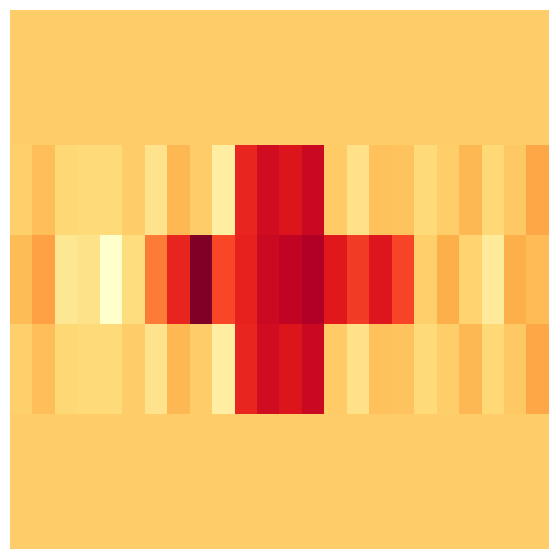

In [30]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= size, out_features=size, bias=False)
    def forward(self, x):
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

W_fc = model.fc.weight

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_fc.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'linear regression - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


# Basic TCL Model

This Model has : 73 parameters
RMSE of Train : 2.63289083030385
RMSE of Test  : 2.0873986316670208


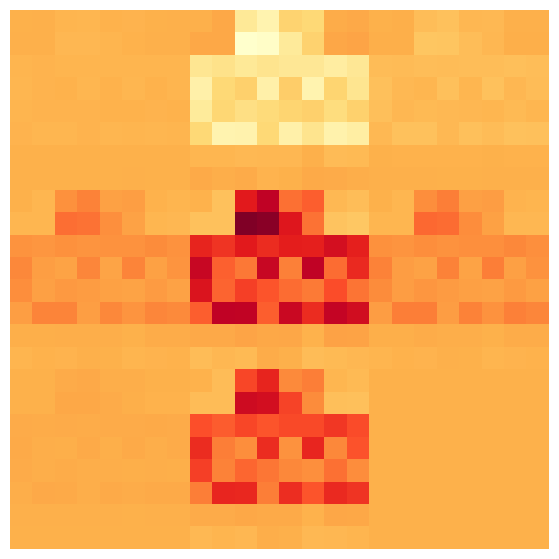

In [41]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        # self.trl = tltorch.TRL(input_shape=(size), rank=(1,1), output_shape=(size), bias=False, factorization='tucker')
        self.tcl = tltorch.TCL(input_shape=(3,size//3), rank=(3,size//3), bias=False)
    def forward(self, x):
        return self.tcl(x.reshape(-1,3,8))
    
model = simple_trl().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 500


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    outputs = outputs.reshape(-1, size)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    
W_tcl1 = model.tcl.factors[0].kron(model.tcl.factors[1])

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train).reshape(-1, size), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test).reshape(-1, size), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_tcl1.detach().cpu().T, cmap='YlOrRd')
plt.axis('off')
# plt.title(f'trl (1,1) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()

# Basic Patch Based Model

model factor shapes
3
torch.Size([3, 3])
torch.Size([2, 2])
torch.Size([4, 4])
This Model has : 29 parameters
RMSE of Train : 2.65750917994725
RMSE of Test  : 2.0286246132546766
RMSE of Ws  : 0.2822296511999157


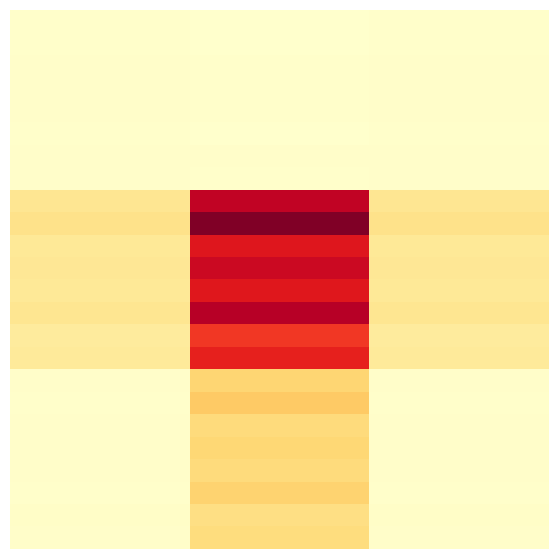

In [45]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.tcl = tltorch.TCL(input_shape=(3,2,4), rank=(3,2,4), bias=False)
    def forward(self, x):
        return self.tcl(x.reshape(-1,3,2,4))
    
model = simple_attached().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    outputs = outputs.reshape(-1,size)
    loss = criterion(outputs, y_train)
    
    loss.backward()
    optimizer.step()

print("model factor shapes")
print(len(model.tcl.factors))
print(model.tcl.factors[0].shape)
print(model.tcl.factors[1].shape)
print(model.tcl.factors[2].shape)
W_attached1 = model.tcl.factors[0].kron(model.tcl.factors[1]).kron(model.tcl.factors[2])

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train).reshape(-1,size), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test).reshape(-1,size), y_test).item())}')
print(f'RMSE of Ws  : {np.sqrt(criterion(W, W_attached1).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached1.detach().cpu().T, cmap='YlOrRd')
plt.axis('off')
# plt.title(f'attached - trl (1,1) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()
